In [156]:
%matplotlib inline
import numpy as np
import pandas as pd
from pylab import *
import matplotlib
#import plplot
from scipy import stats
#from io import StringIO
print(pd.__version__)
#AttributeError: 'Series' object has no attribute 'to_numpy'
import re

import math
import astropy as astro
import scipy.ndimage as spimage
from astropy.io import fits, ascii
from astropy.table import Table, join
from astropy.cosmology import WMAP9 as cosmo
import matplotlib as mpl
#from numpy import std as biweight_midvariance
import matplotlib.cm as cm

from scipy import optimize
from scipy.stats import gaussian_kde
from matplotlib import colors
import scipy.ndimage as ndimage
from collections import Counter
from matplotlib.legend import Legend
import matplotlib.patches as patches
from matplotlib import pyplot
from mpl_toolkits.axes_grid1 import make_axes_locatable
#
#
#
import extinction


#
# seaborn
#import pandas.util.testing as tm
import seaborn as sns

#
# Jorge
#

#from sel2dhist_xy import sel2dhist_xy

from my_tools.sel2dhist_xy import sel2dhist_xy
#
# 3D plots!
#
import numpy as np
import scipy.linalg
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

#biweight_midvariance


import warnings
warnings.simplefilter("ignore")

#
# my_utils
#
from my_tools.my_utils import *

#
#
#
from ndtest import *
from sklearn.decomposition import PCA

#
#
#
from scipy.optimize import leastsq, fmin
import matplotlib.animation as animation

#
# Carlos Color map
#
from my_tools.cmaps_CLC import vel_map

from scipy.spatial import KDTree


import collections

import scipy.stats as st

2.3.3


In [157]:
from matplotlib import rcParams as rc
rc.update({'font.size': 20,\
           'font.weight': 900,\
           'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 20,\
           'ytick.labelsize' : 20,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })


In [184]:
dir_tables = 'tables/'
dir_data = 'data/'


(KGASname,name_now) = ('KGAS66','KG-MaNGA-1-116989')
#(KGASname,name_now) = ('KGAS88','KG-SAMI-107214')
#(KGASname,name_now) = ('KGAS12','KG-MaNGA-1-207')
#(KGASname,name_now) = ('KGAS99','KG-SAMI-93023')
#(KGASname,name_now) = ('KGAS96','KG-SAMI-63777')


READING TABLES

In [185]:
hdu = fits.open(f'{dir_tables}/KG_Pipe3D_table_COSMO.fits')
tab = Table(hdu[1].data)
tab.rename_column('name','org_name')
tab.rename_column('cubename','name')

In [186]:
#
# Map plots!
#
#
# Reading the Pipe3D dataproducts
#
DIR=dir_data


dat=name_now.split("-")
plate=dat[1]
ifu=dat[2]
DIR_plate=DIR
Pipe3D_file=DIR_plate+name_now+".Pipe3D.cube.fits.gz"
Pipe3D_hdu=fits.open(Pipe3D_file)
print(Pipe3D_hdu.info())


PE_file=DIR+name_now+".P_E.cube.fits.gz"
PE_hdu=fits.open(PE_file)
print(PE_hdu.info())

OH_file=DIR+name_now+".OH.cube.fits.gz"
OH_hdu=fits.open(OH_file)
print(OH_hdu.info())

Filename: data/KG-MaNGA-1-116989.Pipe3D.cube.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  ORG_HDR       1 PrimaryHDU      97   ()      
  1  SSP           1 ImageHDU       118   (64, 64, 21)   float64   
  2  SFH           1 ImageHDU      1608   (64, 64, 319)   float64   
  3  INDICES       1 ImageHDU        31   (64, 64, 18)   float64   
  4  ELINES        1 ImageHDU        68   (64, 64, 11)   float64   
  5  FLUX_ELINES    1 ImageHDU      1382   (64, 64, 456)   float64   
  6  FLUX_ELINES_LONG    1 ImageHDU      4622   (64, 64, 1536)   float64   
  7  GAIA_MASK     1 ImageHDU        28   (64, 64)   float64   
  8  SELECT_REG    1 ImageHDU        10   (64, 64)   float64   
None
Filename: data/KG-MaNGA-1-116989.P_E.cube.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     110   (64, 64, 20)   float64   
None
Filename: data/KG-MaNGA-1-116989.OH.cube.fits.gz
No.    Name      Ver    Type      Cards   Dimens

In [187]:
figname=name_now+".SSP"
SELECT_REG_data=Pipe3D_hdu[8].data
SSP_data=Pipe3D_hdu[1].data
SSP_hdr=Pipe3D_hdu[1].header
(nz,ny,nx)=SSP_data.shape
SSP_maps={}
#labels=['V-band img','CS map','DZ map','']
#for i in arange(0,nz,1):
#    key='DESC_'+str(i)
#    val=SSP_hdr[key]
#print(SELECT_REG_data)

SSP_labels={}#np.zeros(nz)
SSP_labels[0]=r'f$_V$'
SSP_labels[1]='CS map'
SSP_labels[2]='DZ map'
SSP_labels[3]=r'f$_{V,CS}$'#DESC_3  median intensity flux within the wavelength range
SSP_labels[4]=r'ef$_{V,CS}$'#  StdDev median intensity flux within the wavelength range
SSP_labels[5]=r'$\mathcal{A}_{\star,L}$'#  luminosity weighted age of the stellar population
SSP_labels[6]=r'$\mathcal{A}_{\star,M}$'#  mass weighted age of the stellar population
SSP_labels[7]=r'e$_{A_\star}$'  #error of the age of the stellar population
SSP_labels[8]=r'$[Z/H]_L$'#  luminosity weighted metallicity of the stellar population
SSP_labels[9]=r'$[Z/H]_M$'#  mass weighted metallicity of the stellar population
SSP_labels[10]=r'e$_{Z}$'#  error metallicity of the stellar population
SSP_labels[11]=r'$A_{V,\star}$'#  average dust attnuation of the stellar population
SSP_labels[12]=r'e$_{Av}$'#  error of the average dust attnuation of the stellar population
SSP_labels[13]=r'vel$_\star$'#  velocity of the stellar population
SSP_labels[14]=r'e$_{vel}$'#  error in the velocity of the stellar population
SSP_labels[15]=r'$\sigma_\star$'#  velocity dispersion of the stellar population
SSP_labels[16]=r'e$_\sigma$'#  error in velocity dispersion of the stellar population
SSP_labels[17]=r'$\gamma_\star$'#  average mass-to-light ratio of the stellar population
SSP_labels[18]=r'$\Sigma_\star$'#  stellar mass density
SSP_labels[19]=r'$\Sigma_{\star,dust}$' #   stellar mass density dust corrected

SSP_ulabels={}#np.zeros(nz)
SSP_ulabels[0]='10$^{-16}$cgs'
SSP_ulabels[1]=''
SSP_ulabels[2]=''
SSP_ulabels[3]=r'10$^{-16}$cgs'#DESC_3  median intensity flux within the wavelength range
SSP_ulabels[4]=r'10$^{-16}$cgs'#  StdDev median intensity flux within the wavelength range
SSP_ulabels[5]=r'Gyr'#  luminosity weighted age of the stellar population
SSP_ulabels[6]=r'Gyr'#  mass weighted age of the stellar population
SSP_ulabels[7]=r'Gyr'  #error of the age of the stellar population
SSP_ulabels[8]=r'dex'#  luminosity weighted metallicity of the stellar population
SSP_ulabels[9]=r'dex'#  mass weighted metallicity of the stellar population
SSP_ulabels[10]=r'dex'#  error metallicity of the stellar population
SSP_ulabels[11]=r'mag'#  average dust attnuation of the stellar population
SSP_ulabels[12]=r'mag'#  error of the average dust attnuation of the stellar population
SSP_ulabels[13]=r'km s$^{-1}$'#  velocity of the stellar population
SSP_ulabels[14]=r'km s$^{-1}$'#  error in the velocity of the stellar population
SSP_ulabels[15]=r'km s$^{-1}$'#  velocity dispersion of the stellar population
SSP_ulabels[16]=r'km s$^{-1}$'#  error in velocity dispersion of the stellar population
SSP_ulabels[17]=r'log(M$_\odot$/L$_\odot$)'#  average mass-to-light ratio of the stellar population
SSP_ulabels[18]=r'log(M$_\odot$/sp$^2$)'#  stellar mass density
SSP_ulabels[19]=r'log(M$_\odot$/sp$^2$)' #   stellar mass density dust corrected



In [188]:
figname=name_now+".SFH"
SELECT_REG_data=Pipe3D_hdu[8].data
SFH_data=Pipe3D_hdu[2].data
SFH_hdr=Pipe3D_hdu[2].header
(nz,ny,nx)=SFH_data.shape
SFH_maps={}
SFH_labels={}
mark_labels={}
for i in arange(0,nz):
    key='DESC_'+str(i)
    SFH_labels[i]=SFH_hdr[key]
    mark_labels_now=SFH_labels[i]
    print(i,mark_labels_now)

0 Luminosity Fraction for age-met 0.0010-0.0001 SSP
1 Luminosity Fraction for age-met 0.0010-0.0005 SSP
2 Luminosity Fraction for age-met 0.0010-0.0020 SSP
3 Luminosity Fraction for age-met 0.0010-0.0080 SSP
4 Luminosity Fraction for age-met 0.0010-0.0170 SSP
5 Luminosity Fraction for age-met 0.0010-0.0300 SSP
6 Luminosity Fraction for age-met 0.0010-0.0400 SSP
7 Luminosity Fraction for age-met 0.0023-0.0001 SSP
8 Luminosity Fraction for age-met 0.0023-0.0005 SSP
9 Luminosity Fraction for age-met 0.0023-0.0020 SSP
10 Luminosity Fraction for age-met 0.0023-0.0080 SSP
11 Luminosity Fraction for age-met 0.0023-0.0170 SSP
12 Luminosity Fraction for age-met 0.0023-0.0300 SSP
13 Luminosity Fraction for age-met 0.0023-0.0400 SSP
14 Luminosity Fraction for age-met 0.0038-0.0001 SSP
15 Luminosity Fraction for age-met 0.0038-0.0005 SSP
16 Luminosity Fraction for age-met 0.0038-0.0020 SSP
17 Luminosity Fraction for age-met 0.0038-0.0080 SSP
18 Luminosity Fraction for age-met 0.0038-0.0170 SSP
19 

In [189]:
figname=name_now+".SFH"
SELECT_REG_data=Pipe3D_hdu[8].data
SFH_data=Pipe3D_hdu[2].data
SFH_hdr=Pipe3D_hdu[2].header
(nz,ny,nx)=SFH_data.shape
SFH_maps={}
SFH_labels={}
mark_labels={}
for i in arange(0,nz):
    key='DESC_'+str(i)
    SFH_labels[i]=SFH_hdr[key]
    mark_labels_now=SFH_labels[i]
    
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for age ','')
    mark_labels_now=mark_labels_now.replace(' SSP','')
    mark_labels[i]=mark_labels_now
#    print(i,mark_labels[i])
#    print(i,SFH_labels[i])

n_start=39*7
I_max=39
n_end=n_start+I_max
SFH_age=SFH_data[n_start:n_end,:,:]
(nz_age,ny_age,nx_age)=SFH_age.shape
print(nx_age,ny_age,nz_age)
n_bin=4
nz_bin=int(np.ceil(nz_age/n_bin))
mark_labels_bin={}
SFH_age_bin=np.zeros((nz_bin,ny_age,nx_age))
label_index={}
for i in arange(0,nz_bin):
    j_min=n_bin*i
    j_max=n_bin*(i+1)+1
    if (j_max>=I_max):
        j_max=I_max-1
    label_index[i]=str(j_min+n_start)+'-'+str(j_max+n_start)
    mark_labels_bin[i]=str(np.around(float(mark_labels[j_min+n_start]),2))+'-'+str(np.around(float(mark_labels[j_max+n_start]),2))+' Gyr'
#    mark_labels[j_min+n_start]+'-'+mark_labels[j_max+n_start]
    for j in arange(j_min,j_max):
        SFH_age_bin[i,:,:]=SFH_age_bin[i,:,:]+SFH_age[j,:,:]
#        print(i,mark_labels_bin[i])
#        print(i,j)



64 64 39


In [190]:
figname=name_now+".SFH_Z"
SELECT_REG_data=Pipe3D_hdu[8].data
SFH_data=Pipe3D_hdu[2].data
SFH_hdr=Pipe3D_hdu[2].header
(nz,ny,nx)=SFH_data.shape
SFH_maps={}
SFH_labels={}
mark_labels={}
#label_index={}
for i in arange(0,nz):
    key='DESC_'+str(i)
    SFH_labels[i]=SFH_hdr[key]
    mark_labels_now=SFH_labels[i]
    
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for age ','')
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for met ','')
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for age-met ','')
    mark_labels_now=mark_labels_now.replace(' SSP','')
    mark_labels[i]=mark_labels_now


In [191]:
figname=name_now+".SFH_L"
SELECT_REG_data=Pipe3D_hdu[8].data
SFH_data=Pipe3D_hdu[2].data
SFH_hdr=Pipe3D_hdu[2].header
(nz,ny,nx)=SFH_data.shape
SFH_maps={}
SFH_labels={}
mark_labels={}
for i in arange(0,nz):
    key='DESC_'+str(i)
    SFH_labels[i]=SFH_hdr[key]
    mark_labels_now=SFH_labels[i]
    
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for age ','')
    mark_labels_now=mark_labels_now.replace(' SSP','')
    mark_labels[i]=mark_labels_now
#    print(i,mark_labels[i])
#    print(i,SFH_labels[i])

n_start=39*7
I_max=39
n_end=n_start+I_max
SFH_age=SFH_data[n_start:n_end,:,:]
(nz_age,ny_age,nx_age)=SFH_age.shape
print(nx_age,ny_age,nz_age)
n_bin=4
nz_bin=int(np.ceil(nz_age/n_bin))
mark_labels_bin={}
SFH_age_bin=np.zeros((nz_bin,ny_age,nx_age))
label_index={}
for i in arange(0,nz_bin):
    j_min=n_bin*i
    j_max=n_bin*(i+1)+1
    if (j_max>=I_max):
        j_max=I_max-1
    label_index[i]=str(j_min+n_start)+'-'+str(j_max+n_start)
    mark_labels_bin[i]=str(np.around(float(mark_labels[j_min+n_start]),2))+'-'+str(np.around(float(mark_labels[j_max+n_start]),2))+' Gyr'
#    mark_labels[j_min+n_start]+'-'+mark_labels[j_max+n_start]
    for j in arange(j_min,j_max):
        SFH_age_bin[i,:,:]=SFH_age_bin[i,:,:]+SFH_age[j,:,:]*SSP_data[0,:,:]#*SSP_data[2,:,:]
#        print(i,mark_labels_bin[i])
#        print(i,j)

print(nz_bin)


64 64 39
10


In [192]:
#catalog_file="tables/SDSS17Pipe3D_v3_1_1.fits"
catalog_hdu=hdu
#print(catalog_hdu.info())
#catalog_tab = Table.read(catalog_hdu[1].data,format='fits')
ssp_data=catalog_hdu[2].data
ssp_hdr=catalog_hdu[2].header
(ny_ssp,nx_ssp)=ssp_data.shape
ssp_norm=[]
ssp_name=[]
ssp_age_met=[]
ssp_age=[]
ssp_met=[]
norm_age={}
norm_met={}
for i in arange(0,ny_ssp):
#    j=i+1
    key='NORM'+str(i)
    norm_now=ssp_hdr[key]
    ssp_norm.append(norm_now)
    key='NAME'+str(i)
    ssp_name_now=ssp_hdr[key]
    ssp_name.append(ssp_hdr[key])
    age_met=ssp_name_now.replace("spec_ssp_","")
    age_met=age_met.replace(".spec","")
    age_met=age_met.replace("_z",",0.")
    ssp_age_met.append(age_met)
    ssp_vals=age_met.split(",")
    age_now=float(ssp_vals[0])
    met_now=float(ssp_vals[1])
    try:
        norm_age[age_now]=norm_age[age_now]+norm_now
    except:        
        norm_age[age_now]=norm_now
    try:
        norm_met[met_now]=norm_met[met_now]+norm_now
    except:        
        norm_met[met_now]=norm_now
        

    ssp_age.append(age_now)
    ssp_met.append(met_now)
#    print(age_now,met_now)
#    print(i,ssp_norm[i])
ssp_norm=np.array(ssp_norm)
ssp_name=np.array(ssp_name)
ssp_age_met=np.array(ssp_age_met)
ssp_age=np.array(ssp_age,float)
ssp_met=np.array(ssp_met,float)
ssp_age=np.unique(ssp_age)
ssp_met=np.unique(ssp_met)
for key in norm_age:
    norm_age[key]=norm_age[key]/len(ssp_met)
for key in norm_met:
    norm_met[key]=norm_met[key]/len(ssp_age)

norm_age_sort={}
norm_met_sort={}
ssp_age=np.sort(ssp_age)
ssp_met=np.sort(ssp_met)
for key in ssp_age:
    norm_age_sort[key]=norm_age[key]
for key in ssp_met:
    norm_met_sort[key]=norm_met[key]

print(norm_age_sort)
print(norm_met_sort)
print(ssp_norm.shape)
#    mark_labels_now=SFH_labels[i]
#plt.imshow(ssp_data)


{np.float64(0.001): 0.006541014285714285, np.float64(0.0023): 0.010148257142857142, np.float64(0.0038): 0.022763142857142853, np.float64(0.00575): 0.011208357142857143, np.float64(0.008): 0.005588271428571429, np.float64(0.0115): 0.004231214285714286, np.float64(0.015): 0.003016471428571428, np.float64(0.02): 0.0026089999999999998, np.float64(0.026): 0.002347214285714286, np.float64(0.033): 0.002120457142857143, np.float64(0.0425): 0.0018480285714285714, np.float64(0.0535): 0.0015954142857142856, np.float64(0.07): 0.0013552142857142858, np.float64(0.09): 0.0011759, np.float64(0.11): 0.0010509157142857143, np.float64(0.14): 0.0009121357142857142, np.float64(0.18): 0.0007814828571428572, np.float64(0.225): 0.0006836342857142857, np.float64(0.275): 0.0006017442857142858, np.float64(0.35): 0.0005100528571428572, np.float64(0.45): 0.0004235842857142858, np.float64(0.55): 0.0003648557142857142, np.float64(0.65): 0.00031986857142857146, np.float64(0.85): 0.00025538000000000004, np.float64(1.1

In [193]:
figname=name_now+".SFH_M"
SELECT_REG_data=Pipe3D_hdu[8].data
SFH_data=Pipe3D_hdu[2].data
SFH_hdr=Pipe3D_hdu[2].header
(nz,ny,nx)=SFH_data.shape
SFH_maps={}
SFH_labels={}
mark_labels={}
for i in arange(0,nz):
    key='DESC_'+str(i)
    SFH_labels[i]=SFH_hdr[key]
    mark_labels_now=SFH_labels[i]
    
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for age ','')
    mark_labels_now=mark_labels_now.replace(' SSP','')
    mark_labels[i]=mark_labels_now
#    print(i,mark_labels[i])
#    print(i,SFH_labels[i])

n_start=39*7
I_max=39
n_end=n_start+I_max
SFH_age=SFH_data[n_start:n_end,:,:]
#ssp_norm_age=ssp_norm[n_start:n_end]
#print(ssp_norm_age.shape,n_start,n_end)
(nz_age,ny_age,nx_age)=SFH_age.shape
print(nx_age,ny_age,nz_age)
sum_ssp_norm=np.zeros((ny_age,nx_age))
img_ones=np.ones((ny_age,nx_age))
ages=[]
for j,key in enumerate(ssp_age):
    sum_ssp_norm=sum_ssp_norm+img_ones*SFH_age[j,:,:]/norm_age_sort[key]
    ages.append(key)
ages=np.array(ages)
 

64 64 39


In [194]:
figname=name_now+".SFH_CM"
SELECT_REG_data=Pipe3D_hdu[8].data
SFH_data=Pipe3D_hdu[2].data
SFH_hdr=Pipe3D_hdu[2].header
(nz,ny,nx)=SFH_data.shape
SFH_maps={}
SFH_labels={}
mark_labels={}
for i in arange(0,nz):
    key='DESC_'+str(i)
    SFH_labels[i]=SFH_hdr[key]
    mark_labels_now=SFH_labels[i]
    
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for age ','')
    mark_labels_now=mark_labels_now.replace(' SSP','')
    mark_labels[i]=mark_labels_now
#    print(i,mark_labels[i])
#    print(i,SFH_labels[i])

n_start=39*7
I_max=39
n_end=n_start+I_max
SFH_age=SFH_data[n_start:n_end,:,:]
(nz_age,ny_age,nx_age)=SFH_age.shape
print(nx_age,ny_age,nz_age)
n_bin=4
nz_bin=int(np.ceil(nz_age/n_bin))
mark_labels_bin={}
SFH_age_bin=np.zeros((nz_bin,ny_age,nx_age))
label_index={}
for i in arange(0,nz_bin):
    j_min=n_bin*i
    j_max=I_max-1#n_bin*(i+1)+1
    #if (j_max>=I_max):
    #    j_max=I_max-1
    label_index[i]=str(j_min+n_start)+'-'+str(j_max+n_start)
    mark_labels_bin[i]=str(np.around(float(mark_labels[j_min+n_start]),2))+'-'+str(np.around(float(mark_labels[j_max+n_start]),2))+' Gyr'
#    mark_labels[j_min+n_start]+'-'+mark_labels[j_max+n_start]
    for j in arange(j_min,j_max):
        key=ages[j]
        SFH_age_bin[i,:,:]=SFH_age_bin[i,:,:]+\
        SFH_age[j,:,:]*10**(SSP_data[18,:,:])*SSP_data[2,:,:]/norm_age_sort[key]
    SFH_age_bin[i,:,:]=np.log10(SFH_age_bin[i,:,:]/sum_ssp_norm)
#    SFH_age_bin[i,:,:]=np.log10(SFH_age_bin[i,:,:])
#    print(i,mark_labels_bin[i])
#        print(i,j)


64 64 39


In [195]:
figname=name_now+".SFH_CM_ALL"
SELECT_REG_data=Pipe3D_hdu[8].data
SFH_data=Pipe3D_hdu[2].data
SFH_hdr=Pipe3D_hdu[2].header
(nz,ny,nx)=SFH_data.shape
SFH_maps={}
SFH_labels={}
mark_labels={}
for i in arange(0,nz):
    key='DESC_'+str(i)
    SFH_labels[i]=SFH_hdr[key]
    mark_labels_now=SFH_labels[i]
    
    mark_labels_now=mark_labels_now.replace('Luminosity Fraction for age ','')
    mark_labels_now=mark_labels_now.replace(' SSP','')
    mark_labels[i]=mark_labels_now
#    print(i,mark_labels[i])
#    print(i,SFH_labels[i])

n_start=39*7
I_max=39
n_end=n_start+I_max
SFH_age=SFH_data[n_start:n_end,:,:]
(nz_age,ny_age,nx_age)=SFH_age.shape
print(nx_age,ny_age,nz_age)
n_bin=1
nz_bin=int(np.ceil(nz_age/n_bin))
mark_labels_bin={}
SFH_age_bin=np.zeros((nz_bin,ny_age,nx_age))
label_index={}
for i in arange(0,nz_bin):
    j_min=n_bin*i
    j_max=I_max-1#n_bin*(i+1)+1
    #if (j_max>=I_max):
    #    j_max=I_max-1
    label_index[i]=str(j_min+n_start)+'-'+str(j_max+n_start)
    mark_labels_bin[i]=str(np.around(float(mark_labels[j_min+n_start]),2))+'-'+str(np.around(float(mark_labels[j_max+n_start]),2))+' Gyr'
#    mark_labels[j_min+n_start]+'-'+mark_labels[j_max+n_start]
    for j in arange(j_min,j_max):
        key=ages[j]
        SFH_age_bin[i,:,:]=SFH_age_bin[i,:,:]+\
        SFH_age[j,:,:]*10**(SSP_data[18,:,:])*SSP_data[2,:,:]/norm_age_sort[key]
    SFH_age_bin[i,:,:]=np.log10(SFH_age_bin[i,:,:]/sum_ssp_norm)
#    SFH_age_bin[i,:,:]=np.log10(SFH_age_bin[i,:,:])
#    print(i,mark_labels_bin[i])
#        print(i,j)


64 64 39


In [196]:
tab_now=tab[tab['name']==name_now]
Re_kpc=tab_now['Re_kpc']
Re_arc=tab_now['Re_arc']
print(Re_kpc,Re_arc)
kpc_to_arc=Re_kpc/Re_arc
kpc_to_sp=kpc_to_arc*0.5

      Re_kpc     
-----------------
4.085353947160739   Re_arc 
---------
7.3594174


In [197]:
figname=name_now+".P_E"
PE_data=PE_hdu[0].data
PE_hdr=PE_hdu[0].header
(nz,ny,nx)=PE_data.shape
PE_maps={}
PE_labels={}

#PE_hdr

PE_labels[9] = r'log($\Sigma_\star$)'
PE_labels[19] = r'log(sSFR)'
PE_labels[11] = r'log($\Sigma_{mol,Av gas log}$)'
PE_labels[17] = r'log($\Sigma_{SFR_{ssp, 100Myr}}$)'
PE_labels[13] = r'log($\Sigma_{mol,Av ssp}$)'
PE_labels[16] = r'log($\Sigma_{SFR,DIG corr}$)'
PE_labels[6] = r'log([OII]/H$\beta$)'
PE_labels[2] = r'A_V'
PE_labels[18] = r'log($\Sigma_{SFR_{ssp, 32Myr}}$)'
PE_labels[12] = r'log($\Sigma_{mol, Av rad}$)'
PE_labels[3] = r'ion. class'
PE_labels[7] = r'log([OIII]/H$\beta$)'
PE_labels[8] = r'$\Upsilon_\star$'
PE_labels[10] = r'log($\Sigma_{mol,Av gas lin}$)'
PE_labels[4] = r'log([NII]/H$\alpha$)'
PE_labels[14] = r'log($\Sigma_{SFR, DIG corr}$)'
PE_labels[5] = r'log([OI]/H$\alpha$)'
PE_labels[15] = r'log($\Sigma_{SFR, H\alpha}$)'
PE_labels[0] = r'f$_V$'
PE_labels[1] = r'R/Re'


In [198]:
#
# We start from principals
#

#
# SFH extension stores the fraction of light in each age bin, so we need to convert it to mass fraction by multiplying the SSP mass-to-light ratio (SSP_data[2,:,:])
# First in Age-Met (39*7), then only in Age bins (39) and finally in Met bins (7)

#
# We use the Age bins only, sum for each metallicity
#
n_start=39*7
I_max=39
n_end=n_start+I_max
SFH_age=SFH_data[n_start:n_end,:,:]
(nz_age,ny_age,nx_age)=SFH_age.shape
#print(nx_age,ny_age,nz_age)
mark_labels_bin={}
Light_by_age_bin=np.zeros((nz_age,ny_age,nx_age))
var_Light_by_age_bin=np.zeros((nz_age,ny_age,nx_age))
Mass_by_age_bin=np.zeros((nz_age,ny_age,nx_age))
var_Mass_by_age_bin=np.zeros((nz_age,ny_age,nx_age))
Sigma_Mass_by_age_bin=np.zeros((nz_age,ny_age,nx_age))
var_Sigma_Mass_by_age_bin=np.zeros((nz_age,ny_age,nx_age))

Mass_total = np.zeros((ny_age,nx_age))
label_index={}
L_erg_sun=((1/(4.84e-9))*(tab_now['DL']*100000/3.08567758e24)**2)/10**(-0.4*(4.86))/(3600*2)

for i in arange(0,nz_age):
    label_index[i]=str(j_min+n_start)+'-'+str(j_max+n_start)
    mark_labels_bin[i]=str(np.around(float(mark_labels[j_min+n_start]),2))+'-'+str(np.around(float(mark_labels[j_max+n_start]),2))+' Gyr'
    j = i
    #
    # Flux in each age bin
    #
    Light_by_age_bin[i,:,:]=Light_by_age_bin[i,:,:]+SFH_age[j,:,:]*SSP_data[0,:,:]*10**(0.4*SSP_data[11,:,:])*1e-16
    var_Light_by_age_bin[i,:,:] = var_Light_by_age_bin[i,:,:]+\
        SFH_age[j,:,:]*(SSP_data[4,:,:]**2*10**(0.4*SSP_data[11,:,:])+SSP_data[0,:,:]*SSP_data[12,:,:]*10**(0.8*SSP_data[11,:,:]))*1e-16
    #
    # Mass per spaxel in each age_bin
    #
    Mass_by_age_bin[i,:,:]=Light_by_age_bin[i,:,:]/norm_age[ages[j]]*L_erg_sun
    var_Mass_by_age_bin[i,:,:] = var_Light_by_age_bin[i,:,:]/norm_age[ages[j]]*L_erg_sun
    #        print(i,j,ages[j],norm_age[ages[j]])
    #
    # Sigma Mass per spaxel in each age_bin
    #
    Sigma_Mass_by_age_bin[i,:,:]=Mass_by_age_bin[i,:,:]/((1000*kpc_to_sp)**2)
    var_Sigma_Mass_by_age_bin[i,:,:] = var_Mass_by_age_bin[i,:,:]/(1000*kpc_to_sp)**2
    #print(i,j,ages[j],norm_age[ages[j]])
    Mass_total = Mass_total + Mass_by_age_bin[i,:,:]
#Mass_total = Mass_by_age_bin[nz_bin-1,:,:]
time_to_SFR_32=32e-3
time_to_SFR_100=100e-3
ind_32=np.argmin(np.abs(ages-time_to_SFR_32))
ind_100=np.argmin(np.abs(ages-time_to_SFR_100))
print(ind_32,time_to_SFR_32,ages[ind_32])
print(ind_100,time_to_SFR_100,ages[ind_100])

Sigma_Mass_32Myr = np.nansum(Sigma_Mass_by_age_bin[0:ind_32,:,:], axis=0)
Sigma_Mass_100Myr = np.nansum(Sigma_Mass_by_age_bin[0:ind_100,:,:], axis=0)
var_Sigma_Mass_32Myr = np.nansum(var_Sigma_Mass_by_age_bin[0:ind_32,:,:], axis=0)
var_Sigma_Mass_100Myr = np.nansum(var_Sigma_Mass_by_age_bin[0:ind_100,:,:], axis=0)

log_Sigma_SFR_32Myr = np.log10(Sigma_Mass_32Myr/(time_to_SFR_32*1e9))
log_Sigma_SFR_100Myr = np.log10(Sigma_Mass_100Myr/(time_to_SFR_100*1e9))
e_log_Sigma_SFR_32Myr = 0.434*var_Sigma_Mass_32Myr**0.5/Sigma_Mass_32Myr
e_log_Sigma_SFR_100Myr = 0.434*var_Sigma_Mass_100Myr**0.5/Sigma_Mass_100Myr

Sigma_Mass_all = np.nansum(Sigma_Mass_by_age_bin, axis=0)
var_Sigma_Mass_all = np.nansum(var_Sigma_Mass_by_age_bin,axis=0)

log_Sigma_Mass_all = np.log10(Sigma_Mass_all)
e_log_Sigma_Mass_all = 0.434*var_Sigma_Mass_all**0.5/Sigma_Mass_all

#
# There is a minimum error that comes from the original photometry
#

e_log_Sigma_SFR_32Myr = e_log_Sigma_SFR_32Myr + tab_now['e_log_Mass']
e_log_Sigma_SFR_100Myr = e_log_Sigma_SFR_100Myr + tab_now['e_log_Mass']
e_log_Sigma_Mass_all = e_log_Sigma_Mass_all + tab_now['e_log_Mass']



9 0.032 0.033
14 0.1 0.11


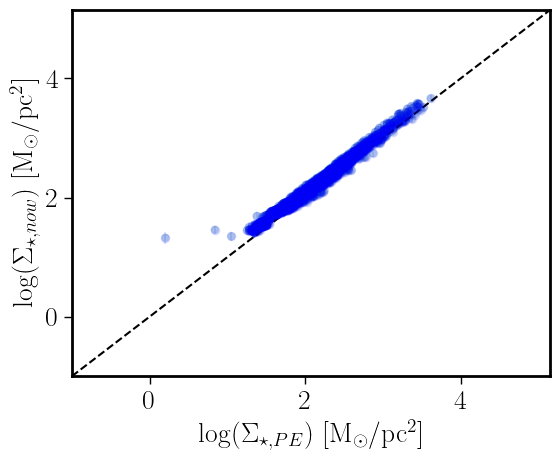

In [199]:
fig, ax = plt.subplots(figsize=(6,5))

ax.scatter((PE_data[9,:,:]),log_Sigma_Mass_all,edgecolor='None',alpha=0.3)
ax.errorbar((PE_data[9,:,:].flatten()), log_Sigma_Mass_all.flatten(), yerr=e_log_Sigma_Mass_all.flatten(), fmt='o', alpha=0.1, color='blue')
ax.set_xlabel(r'log($\Sigma_{\star, PE}$) [M$_\odot$/pc$^2$]')
ax.set_ylabel(r'log($\Sigma_{\star, now}$) [M$_\odot$/pc$^2$]')
ax.plot([-1,5.15],[-1,5.15], 'k--')
ax.set_xlim(-1,5.15)
ax.set_ylim(-1,5.15)
plt.tight_layout()
fig.savefig(f"figs/{name_now}.Sigma_Mass_now_vs_PE.png", transparent=False, facecolor='white', edgecolor='white')#.png")


-8.051706976310765
-8.336094433280808


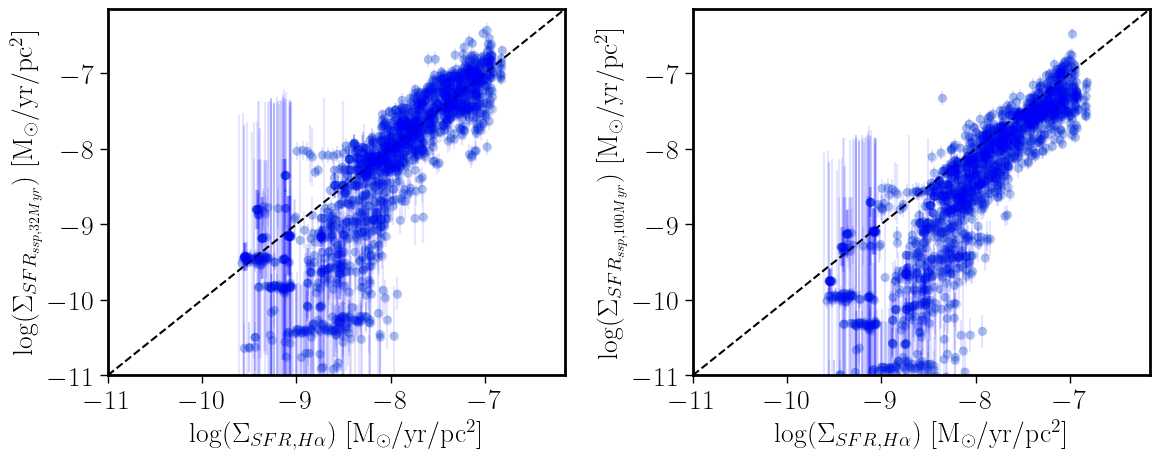

In [200]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
#ax.scatter(PE_data[15,:,:],PE_data[18,:,:])
ax[0].scatter(PE_data[15,:,:],log_Sigma_SFR_32Myr,edgecolor='None',alpha=0.3)
ax[0].errorbar(PE_data[15,:,:].flatten(), log_Sigma_SFR_32Myr.flatten(), yerr=e_log_Sigma_SFR_32Myr.flatten(), fmt='o', alpha=0.1, color='blue')
ax[0].set_xlabel(r'log($\Sigma_{SFR, H\alpha}$) [M$_\odot$/yr/pc$^2$]')
ax[0].set_ylabel(r'log($\Sigma_{SFR_{ssp, 32Myr}}$) [M$_\odot$/yr/pc$^2$]')
ax[0].plot([-11,-6.15],[-11,-6.15], 'k--')
ax[0].set_xlim(-11,-6.15)
ax[0].set_ylim(-11,-6.15)

ax[1].scatter(PE_data[15,:,:],log_Sigma_SFR_100Myr,edgecolor='None',alpha=0.3)
ax[1].errorbar(PE_data[15,:,:].flatten(), log_Sigma_SFR_100Myr.flatten(), yerr=e_log_Sigma_SFR_100Myr.flatten(), fmt='o', alpha=0.1, color='blue')
ax[1].set_xlabel(r'log($\Sigma_{SFR, H\alpha}$) [M$_\odot$/yr/pc$^2$]')
ax[1].set_ylabel(r'log($\Sigma_{SFR_{ssp, 100Myr}}$) [M$_\odot$/yr/pc$^2$]')
ax[1].plot([-11,-6.15],[-11,-6.15], 'k--')
ax[1].set_xlim(-11,-6.15)
ax[1].set_ylim(-11,-6.15)

print(np.median(log_Sigma_SFR_32Myr[:,:][log_Sigma_SFR_32Myr[:,:]>-12]))
print(np.median(log_Sigma_SFR_100Myr[:,:][log_Sigma_SFR_100Myr[:,:]>-12]))
plt.tight_layout()
fig.savefig(f"figs/{name_now}.Sigma_SFR_Ha_vs_SSP.png", transparent=False, facecolor='white', edgecolor='white')#.png")

In [201]:
#
# Correcting the V_disp to show km/s intead of Angstroms
#

#
# 
#
FELINES_data=Pipe3D_hdu[5].data
FELINES_hdr=Pipe3D_hdu[5].header
(nz_fe,ny_fe,nx_fe)=FELINES_data.shape

#img_disp=FELINES_data[159,:,:]
#img_e_disp=FELINES_data[387,:,:]

nf=0.25
img_Ha=FELINES_data[45,:,:]
img_e_Ha=nf*FELINES_data[273,:,:]
img_WHa=FELINES_data[216,:,:]
img_e_WHa=nf*FELINES_data[444,:,:]
img_disp=FELINES_data[159,:,:]
img_e_disp=FELINES_data[387,:,:]
img_OIII=FELINES_data[26,:,:]
img_e_OIII=nf*FELINES_data[254,:,:]
img_Hb=FELINES_data[28,:,:]
img_e_Hb=nf*FELINES_data[256,:,:]
img_NII=FELINES_data[46,:,:]
img_e_NII=nf*FELINES_data[274,:,:]
img_OII=FELINES_data[0,:,:]
img_e_OII=FELINES_data[228,:,:]
img_OI=FELINES_data[41,:,:]
img_e_OI=FELINES_data[269,:,:]
img_SII_6717=FELINES_data[49,:,:]
img_e_SII_6717=nf*FELINES_data[277,:,:]
img_SII_6731=FELINES_data[50,:,:]
img_e_SII_6731=nf*FELINES_data[278,:,:]
img_SII=img_SII_6717+img_SII_6731
img_e_SII=np.sqrt(img_e_SII_6717**2+img_e_SII_6731**2)
log_SII_Ha=np.log10(img_SII/img_Ha)
e_log_SII_Ha=np.sqrt((img_e_SII/img_SII)**2+(img_e_Ha/img_Ha)**2)/np.log(10)
rat_SII = img_SII_6717/img_SII_6731
e_rat_SII = img_e_SII_6717/img_SII_6731+img_e_SII_6731*img_SII_6717/img_SII_6731**2

if (name_now.find("SAMI")>=0):
    inst_disp = 1.0
else:
    inst_disp = 1.4

img_disp_kms = np.sqrt((img_disp/2.354)**2-inst_disp**2)/6562*300000
img_disp_kms = img_disp_kms/np.sqrt(2.354)
e_img_disp_kms=0.1*img_e_disp/6562*300000/2.354

In [202]:
for i in arange(0,nz_fe):
    key='NAME'+str(i)
    key_w = 'wave'+str(i)
    if (FELINES_hdr[key].find("[SII]")>=0):
        print(i,key,FELINES_hdr[key],FELINES_hdr[key_w])


11 NAME11 flux [SII] 4069.17
12 NAME12 flux [SII] 4076.72
49 NAME49 flux [SII]6717 6716.39
50 NAME50 flux [SII]6731 6730.74
68 NAME68 vel [SII] 4069.17
69 NAME69 vel [SII] 4076.72
106 NAME106 vel [SII]6717 6716.39
107 NAME107 vel [SII]6731 6730.74
125 NAME125 disp [SII] 4069.17
126 NAME126 disp [SII] 4076.72
163 NAME163 disp [SII]6717 6716.39
164 NAME164 disp [SII]6731 6730.74
182 NAME182 EW [SII] 4069.17
183 NAME183 EW [SII] 4076.72
220 NAME220 EW [SII]6717 6716.39
221 NAME221 EW [SII]6731 6730.74
239 NAME239 e_flux [SII] 4069.17
240 NAME240 e_flux [SII] 4076.72
277 NAME277 e_flux [SII]6717 6716.39
278 NAME278 e_flux [SII]6731 6730.74
296 NAME296 e_vel [SII] 4069.17
297 NAME297 e_vel [SII] 4076.72
334 NAME334 e_vel [SII]6717 6716.39
335 NAME335 e_vel [SII]6731 6730.74
353 NAME353 e_disp [SII] 4069.17
354 NAME354 e_disp [SII] 4076.72
391 NAME391 e_disp [SII]6717 6716.39
392 NAME392 e_disp [SII]6731 6730.74
410 NAME410 e_EW [SII] 4069.17
411 NAME411 e_EW [SII] 4076.72
448 NAME448 e_EW [

In [203]:
#FELINES_hdr

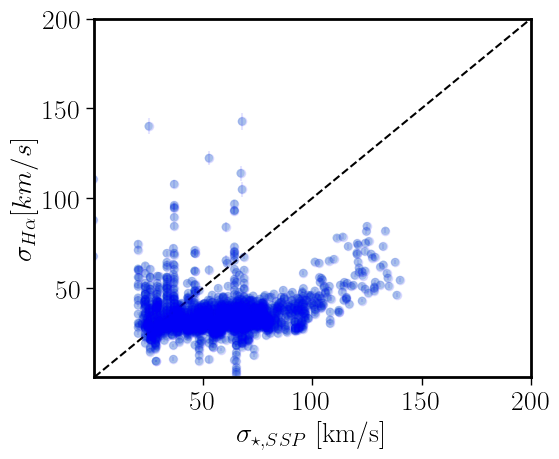

In [204]:
fig, ax = plt.subplots(figsize=(6,5))

ax.scatter((SSP_data[15,:,:]),img_disp_kms,edgecolor='None',alpha=0.3)
ax.errorbar((SSP_data[15,:,:].flatten()), img_disp_kms.flatten(), yerr=e_img_disp_kms.flatten(), fmt='o', alpha=0.1, color='blue')
ax.set_xlabel(r'$\sigma_{\star, SSP}$ [km/s]')
ax.set_ylabel(r'$\sigma_{H\alpha} [km/s]$')
ax.plot([0.5,200],[0.5,200], 'k--')
ax.set_xlim(0.5,200)
ax.set_ylim(0.5,200)
plt.tight_layout()
fig.savefig(f"figs/{name_now}.disp_st_gas.png", transparent=False, facecolor='white', edgecolor='white')#.png")

In [205]:
file_out=name_now+".P_E_new.cube.fits.gz"
PE_data=PE_hdu[0].data
PE_hdr=PE_hdu[0].header
(nz_pe,ny_pe,nx_pe)=PE_data.shape

PE_new_data=np.zeros(((nz_pe+1)*2,ny_pe,nx_pe))

PE_new_data[0:nz_pe,:,:]=PE_data
#PE_new_data[9,:,:]=log_Sigma_Mass_all
PE_new_data[17,:,:]=log_Sigma_SFR_100Myr
PE_new_data[18,:,:]=log_Sigma_SFR_32Myr

#PE_new_data[10,:,:]=log_SII_Ha
#PE_new_data[12,:,:]=rat_SII

#
#PE_new_data[9+nz_pe+1,:,:]=np.abs(e_log_Sigma_Mass_all)
PE_new_data[17+nz_pe+1,:,:]=np.abs(e_log_Sigma_SFR_100Myr)
PE_new_data[18+nz_pe+1,:,:]=np.abs(e_log_Sigma_SFR_32Myr)
#
#


PE_new_data[8,:,:]=log_SII_Ha
PE_new_data[9,:,:]=rat_SII
PE_new_data[10,:,:]=log_Sigma_Mass_all
PE_new_data[11,:,:]=PE_data[8,:,:]
PE_new_data[12,:,:]=PE_data[11,:,:]

PE_new_data[10+nz_pe+1,:,:]=np.abs(e_log_Sigma_Mass_all)
#
# 8 Mass-to-Light ratio from SSP analysis  -> 11
# 9 Log Stellar mass surface density       -> 10
# 10 [SII] vs Ha line ratio LOG            -> 8
# 11 Log Molecular mass surface density from Av using a log-linear rel   -> 12
# 12 rat_SII                               -> 9


PE_new_data[20,:,:]=img_disp_kms
PE_new_data[20+nz_pe+1,:,:]=np.abs(e_img_disp_kms)

PE_new_hdr=PE_hdr.copy()
PE_new_hdr['NZ']=(nz_pe+1)*2

PE_new_hdr['DESC_10']=PE_hdr['DESC_9']
PE_new_hdr['DESC_11']=PE_hdr['DESC_8']
PE_new_hdr['DESC_12']=PE_hdr['DESC_11']

i = 20
i_err = 20+nz_pe+1
PE_new_hdr[f'DESC_{i}'] = 'Halpha velocity dispersion [km/s]'
PE_new_hdr[f'DESC_{i_err}'] = 'err. ' + PE_new_hdr[f'DESC_{i}']

i = 8
i_err = 8+nz_pe+1
PE_new_hdr[f'DESC_{i}'] = '[SII] vs Ha line ratio LOG'
PE_new_hdr[f'DESC_{i_err}'] = 'err. ' + PE_new_hdr[f'DESC_{i}']

i = 9
i_err = 9+nz_pe+1
PE_new_hdr[f'DESC_{i}'] = 'rat_SII'
PE_new_hdr[f'DESC_{i_err}'] = 'err. ' + PE_new_hdr[f'DESC_{i}']

for i in arange(4,8):
    PE_new_hdr[f'DESC_{i}'] = PE_new_hdr[f'DESC_{i}'] + ' LOG '

for i in arange(0,nz_pe):
    i_err = i+nz_pe+1
    key = f'DESC_{i}'
    key_err = f'DESC_{i_err}'
    PE_new_hdr[key_err] = 'err. '+PE_new_hdr[key]

#
# Adding more errors
#

PE_new_data[0+nz_pe+1,:,:]=np.abs(SSP_data[4,:,:])
PE_new_data[1+nz_pe+1,:,:]=0
PE_new_data[2+nz_pe+1,:,:]=np.abs(2.5*(img_e_Ha/img_Hb))
PE_new_data[3+nz_pe+1,:,:]=0
PE_new_data[4+nz_pe+1,:,:]=np.abs(0.434*(img_e_NII/img_Ha+img_e_Ha*(img_NII/img_Ha**2)))
PE_new_data[5+nz_pe+1,:,:]=np.abs(0.434*(img_e_OI/img_Ha+img_e_Hb*(img_OI/img_Ha**2)))
PE_new_data[6+nz_pe+1,:,:]=np.abs(0.434*(img_e_OII/img_Hb+img_e_Hb*(img_OII/img_Hb**2)))
PE_new_data[7+nz_pe+1,:,:]=np.abs(0.434*(img_e_OIII/img_Hb+img_e_Hb*(img_OIII/img_Hb**2)))
PE_new_data[8+nz_pe+1,:,:]=np.abs(e_log_SII_Ha)
PE_new_data[9+nz_pe+1,:,:]=np.abs(e_rat_SII)
PE_new_data[10+nz_pe+1,:,:]=np.abs(e_log_Sigma_Mass_all)#*PE_new_data[8])
PE_new_data[11+nz_pe+1,:,:]=np.abs(e_log_Sigma_Mass_all)+np.abs(SSP_data[4,:,:]/SSP_data[3,:,:])
PE_new_data[12+nz_pe+1,:,:]=np.abs(0.434*PE_new_data[2+nz_pe+1,:,:]+0.434*img_e_Ha/img_Ha+0.1)
PE_new_data[13+nz_pe+1,:,:]=np.abs(0.434*SSP_data[12,:,:]+0.434*img_e_Ha/img_Ha+0.15)
PE_new_data[14+nz_pe+1,:,:]=np.abs(0.434*img_e_Ha/img_Ha+SSP_data[4,:,:]/SSP_data[3,:,:]+0.05+0.434*PE_new_data[2+nz_pe+1,:,:])
PE_new_data[15+nz_pe+1,:,:]=np.abs(0.434*img_e_Ha/img_Ha+0.05+0.434*PE_new_data[2+nz_pe+1,:,:])
PE_new_data[16+nz_pe+1,:,:]=np.abs(0.434*img_e_Ha/img_Ha+SSP_data[4,:,:]/SSP_data[3,:,:]+0.05+0.434*PE_new_data[2+nz_pe+1,:,:])
PE_new_data[19+nz_pe+1,:,:]=np.abs(PE_new_data[14+nz_pe+1,:,:]+PE_new_data[8+nz_pe+1,:,:])  



In [206]:
for i in arange(0,2*(nz_pe+1)):
    key = f'DESC_{i}'
    print (i,PE_new_hdr[key])


0 pseudo V-band map
1 galactocentric distance
2 dust attenuation V-band
3 ionization classification using the BPT+EW_Ha
4 [NII] vs. Ha line ratio LOG
5 [OI] vs Ha line ratio LOG
6 [OII] vs Hb line ratio LOG
7 [OIII] vs Hb line ratio LOG
8 [SII] vs Ha line ratio LOG
9 rat_SII
10 Log Stellar mass surface density
11 Mass-to-Light ratio from SSP analysis
12 Log Molecular mass surface density from Av using a log-linear rel
13 Log Molecular mass surface density from Av from ssp using a linea
14 Log SFR surface density from Ha corrected by dust and DIG
15 Log SFR surface density from Ha corrected by dust
16 Log SFR surface density from Ha corrected by dust and DIG with a
17 Log SFR surface density derived from the SSP analysis up to 100My
18 Log SFR surface density derived from the SSP analysis up to 32Myr
19 Log sSFR
20 Halpha velocity dispersion [km/s]
21 err. pseudo V-band map
22 err. galactocentric distance
23 err. dust attenuation V-band
24 err. ionization classification using the BPT+EW

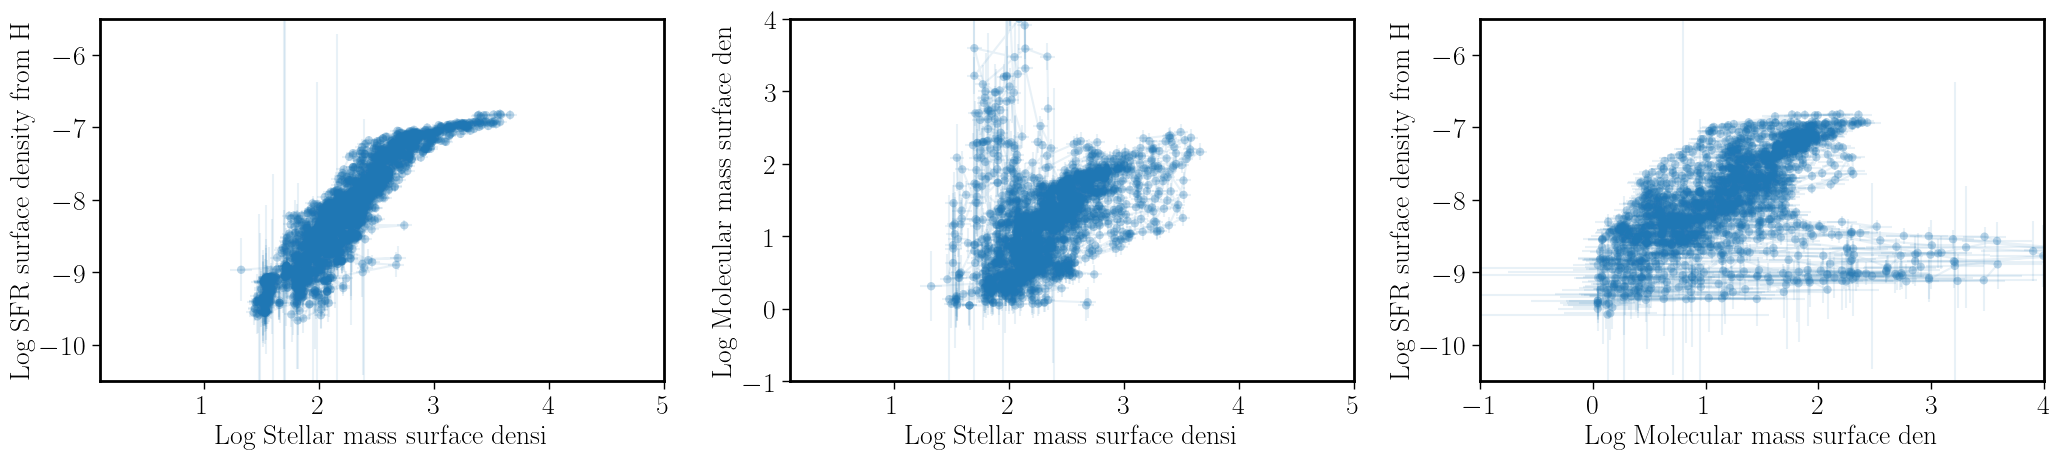

In [207]:
fig, ax = plt.subplots(1,3,figsize=(21,5))

i = 10
j = 15
desc_i = PE_new_hdr[f'DESC_{i}']    
desc_j = PE_new_hdr[f'DESC_{j}']
ax[0].scatter(PE_new_data[i,:,:],PE_new_data[j,:,:],edgecolor='None',alpha=0.3)
ax[0].errorbar(PE_new_data[i,:,:].flatten(),PE_new_data[j,:,:].flatten(), \
            xerr=PE_new_data[i+nz_pe+1,:,:].flatten(), \
            yerr=np.abs(PE_new_data[j+nz_pe+1,:,:].flatten()), alpha=0.1) #, fmt='o', alpha=0.1, color='blue')
ax[0].set_xlabel(rf'{desc_i[0:30]}')
ax[0].set_ylabel(rf'{desc_j[0:30]}')
#ax[0].plot([0.5,200],[0.5,200], 'k--')
ax[0].set_xlim(0.1,5)
ax[0].set_ylim(-10.5,-5.5)

i = 10
j = 12
desc_i = PE_new_hdr[f'DESC_{i}']    
desc_j = PE_new_hdr[f'DESC_{j}']
ax[1].scatter(PE_new_data[i,:,:],PE_new_data[j,:,:],edgecolor='None',alpha=0.3)
ax[1].errorbar(PE_new_data[i,:,:].flatten(),PE_new_data[j,:,:].flatten(), \
            xerr=PE_new_data[i+nz_pe+1,:,:].flatten(), \
            yerr=np.abs(PE_new_data[j+nz_pe+1,:,:].flatten()), alpha=0.1) #, fmt='o', alpha=0.1, color='blue')
ax[1].set_xlabel(rf'{desc_i[0:30]}')
ax[1].set_ylabel(rf'{desc_j[0:30]}')
#ax[0].plot([0.5,200],[0.5,200], 'k--')
ax[1].set_xlim(0.1,5)
ax[1].set_ylim(-1,4)

i = 12
j = 15
desc_i = PE_new_hdr[f'DESC_{i}']    
desc_j = PE_new_hdr[f'DESC_{j}']
ax[2].scatter(PE_new_data[i,:,:],PE_new_data[j,:,:],edgecolor='None',alpha=0.3)
ax[2].errorbar(PE_new_data[i,:,:].flatten(),PE_new_data[j,:,:].flatten(), \
            xerr=PE_new_data[i+nz_pe+1,:,:].flatten(), \
            yerr=np.abs(PE_new_data[j+nz_pe+1,:,:].flatten()), alpha=0.1) #, fmt='o', alpha=0.1, color='blue')
ax[2].set_xlabel(rf'{desc_i[0:30]}')
ax[2].set_ylabel(rf'{desc_j[0:30]}')
#ax[0].plot([0.5,200],[0.5,200], 'k--')
ax[2].set_xlim(-1,4)
ax[2].set_ylim(-10.5,-5.5)

plt.tight_layout()
fig.savefig(f"figs/{name_now}.rRelation.png", transparent=False, facecolor='white', edgecolor='white')#.png")

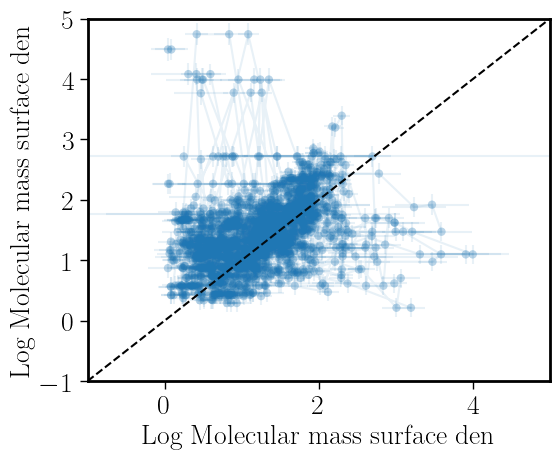

In [208]:
fig, ax = plt.subplots(1,figsize=(6,5))



i = 12
j = 13
desc_i = PE_new_hdr[f'DESC_{i}']    
desc_j = PE_new_hdr[f'DESC_{j}']
ax.scatter(PE_new_data[i,:,:],PE_new_data[j,:,:],edgecolor='None',alpha=0.3)
ax.errorbar(PE_new_data[i,:,:].flatten(),PE_new_data[j,:,:].flatten(), \
            xerr=PE_new_data[i+nz_pe+1,:,:].flatten(), \
            yerr=np.abs(PE_new_data[j+nz_pe+1,:,:].flatten()), alpha=0.1) #, fmt='o', alpha=0.1, color='blue')
ax.set_xlabel(rf'{desc_i[0:30]}')
ax.set_ylabel(rf'{desc_j[0:30]}')
ax.plot([-1,5],[-1,5], 'k--')
ax.set_xlim(-1,5)
ax.set_ylim(-1,5)


plt.tight_layout()
fig.savefig(f"figs/{name_now}.Sgas.png", transparent=False, facecolor='white', edgecolor='white')#.png")

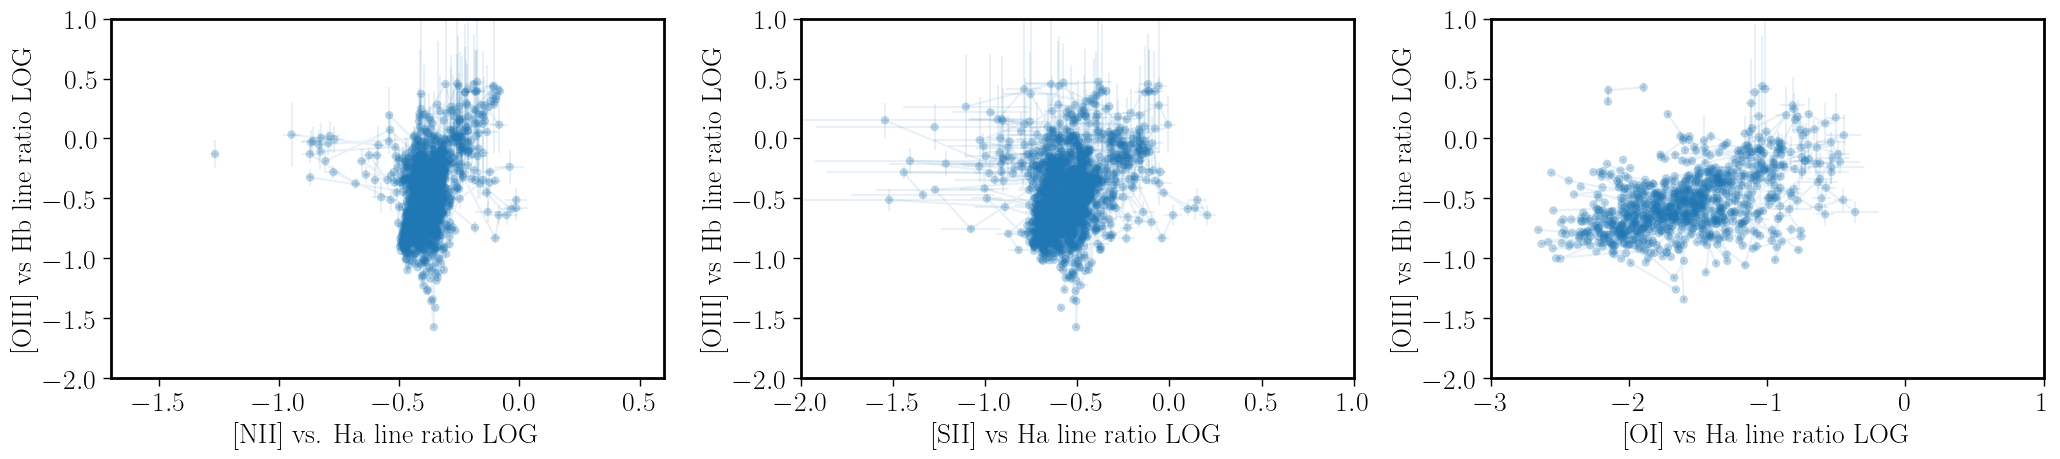

In [209]:
fig, ax = plt.subplots(1,3,figsize=(21,5))

i = 4
j = 7
desc_i = PE_new_hdr[f'DESC_{i}']    
desc_j = PE_new_hdr[f'DESC_{j}']
ax[0].scatter(PE_new_data[i,:,:],PE_new_data[j,:,:],edgecolor='None',alpha=0.3)
ax[0].errorbar(PE_new_data[i,:,:].flatten(),PE_new_data[j,:,:].flatten(), \
            xerr=PE_new_data[i+nz_pe+1,:,:].flatten(), \
            yerr=np.abs(PE_new_data[j+nz_pe+1,:,:].flatten()), alpha=0.1) #, fmt='o', alpha=0.1, color='blue')
ax[0].set_xlabel(rf'{desc_i[0:30]}')
ax[0].set_ylabel(rf'{desc_j[0:30]}')
#ax[0].plot([0.5,200],[0.5,200], 'k--')
ax[0].set_xlim(-1.7,0.6)
ax[0].set_ylim(-2,1)

i = 8
j = 7
desc_i = PE_new_hdr[f'DESC_{i}']    
desc_j = PE_new_hdr[f'DESC_{j}']
ax[1].scatter(PE_new_data[i,:,:],PE_new_data[j,:,:],edgecolor='None',alpha=0.3)
ax[1].errorbar(PE_new_data[i,:,:].flatten(),PE_new_data[j,:,:].flatten(), \
            xerr=PE_new_data[i+nz_pe+1,:,:].flatten(), \
            yerr=np.abs(PE_new_data[j+nz_pe+1,:,:].flatten()), alpha=0.1) #, fmt='o', alpha=0.1, color='blue')
ax[1].set_xlabel(rf'{desc_i[0:30]}')
ax[1].set_ylabel(rf'{desc_j[0:30]}')
#ax[0].plot([0.5,200],[0.5,200], 'k--')
ax[1].set_xlim(-2,1)
ax[1].set_ylim(-2,1)

i = 5
j = 7
desc_i = PE_new_hdr[f'DESC_{i}']    
desc_j = PE_new_hdr[f'DESC_{j}']
ax[2].scatter(PE_new_data[i,:,:],PE_new_data[j,:,:],edgecolor='None',alpha=0.3)
ax[2].errorbar(PE_new_data[i,:,:].flatten(),PE_new_data[j,:,:].flatten(), \
            xerr=PE_new_data[i+nz_pe+1,:,:].flatten(), \
            yerr=np.abs(PE_new_data[j+nz_pe+1,:,:].flatten()), alpha=0.1) #, fmt='o', alpha=0.1, color='blue')
ax[2].set_xlabel(rf'{desc_i[0:30]}')
ax[2].set_ylabel(rf'{desc_j[0:30]}')
#ax[0].plot([0.5,200],[0.5,200], 'k--')
ax[2].set_xlim(-3,1)
ax[2].set_ylim(-2,1)

plt.tight_layout()
fig.savefig(f"figs/{name_now}.BPT.png", transparent=False, facecolor='white', edgecolor='white')#.png")

In [210]:
(vmin,vmax,vmed,vstd)=(np.min(PE_new_data[j,:,:]),np.max(PE_new_data[j,:,:]),np.median(PE_new_data[j,:,:]),np.std(PE_new_data[j,:,:]))
print(vmin,vmax,vmed,vstd)

-1.7976931348623157e+308 0.4730019561090645 -inf inf


In [211]:
hdr_clean = PE_new_hdr.copy()

bad_continue_indices = [
    i for i, card in enumerate(hdr_clean.cards)
    if card.keyword == 'CONTINUE' and not isinstance(card.value, str)
]

for i in reversed(bad_continue_indices):
    hdr_clean.remove(hdr_clean.cards[i].keyword, remove_all=False)



hdu_out = fits.PrimaryHDU(data=PE_new_data,header=hdr_clean)
hdu_list =fits.HDUList([hdu_out])
hdu_list.writeto(f'{dir_data}/{file_out}', overwrite=True, output_verify='silentfix')